# Predicciones vs Real — Zonas concretas

Validación visual del modelo Linear Regression sobre el mes de test (marzo 2025).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

## 1. Cargar datos y entrenar modelo

In [11]:
df = pd.read_parquet('../../data/processed/yellow_taxi_features.parquet')
print(f'Shape: {df.shape}')
print(f'Fechas: {df["pickup_datetime"].min()} a {df["pickup_datetime"].max()}')

Shape: (2850381, 23)
Fechas: 2024-01-01 00:00:00 a 2025-03-31 00:00:00


In [12]:
FEATURE_COLS = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'hour_of_week',
    'is_holiday', 'is_holiday_eve',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_168h',
    'rolling_mean_3h', 'rolling_mean_12h', 'rolling_mean_24h', 'rolling_mean_168h'
]
TARGET = 'trip_count'
TEST_DATE = '2025-03-01'

train = df[df['pickup_datetime'] < TEST_DATE]
test  = df[df['pickup_datetime'] >= TEST_DATE]

model = LinearRegression()
model.fit(train[FEATURE_COLS].fillna(0), train[TARGET])

# Predicciones para todo el test set
test = test.copy()
test['y_pred'] = model.predict(test[FEATURE_COLS].fillna(0))
test['y_pred'] = test['y_pred'].clip(lower=0)  # sin predicciones negativas

mae_global = mean_absolute_error(test[TARGET], test['y_pred'])
print(f'Modelo entrenado. MAE global en test: {mae_global:.4f}')
print(f'Train: {len(train):,} filas  |  Test: {len(test):,} filas')

Modelo entrenado. MAE global en test: 0.1429
Train: 2,662,200 filas  |  Test: 188,181 filas


## 2. Zonas a analizar

Usamos las 5 zonas más activas de enero 2025 (del EDA):
- **161** — Midtown Center
- **237** — Upper East Side South
- **236** — Upper East Side North
- **132** — JFK Airport
- **230** — Times Square / Midtown West

In [13]:
ZONAS = {
    161: 'Midtown Center',
    237: 'Upper East Side South',
    236: 'Upper East Side North',
    132: 'JFK Airport',
    230: 'Times Sq / Midtown West',
}

print('MAE por zona (test set completo - marzo 2025):')
print(f'{"Zona":<8} {"Nombre":<26} {"MAE":<8} {"RMSE":<8} {"Media real":<12}')
print('-' * 65)

for zone_id, zone_name in ZONAS.items():
    z = test[test['PULocationID'] == zone_id]
    mae_z = mean_absolute_error(z[TARGET], z['y_pred'])
    rmse_z = np.sqrt(mean_squared_error(z[TARGET], z['y_pred']))
    mean_real = z[TARGET].mean()
    print(f'{zone_id:<8} {zone_name:<26} {mae_z:<8.2f} {rmse_z:<8.2f} {mean_real:<12.1f}')

MAE por zona (test set completo - marzo 2025):
Zona     Nombre                     MAE      RMSE     Media real  
-----------------------------------------------------------------
161      Midtown Center             1.42     1.92     208.0       
237      Upper East Side South      1.14     1.50     201.6       
236      Upper East Side North      1.06     1.50     175.2       
132      JFK Airport                1.54     2.01     193.2       
230      Times Sq / Midtown West    1.26     1.74     154.1       


## 3. Predicción vs Real — semana completa

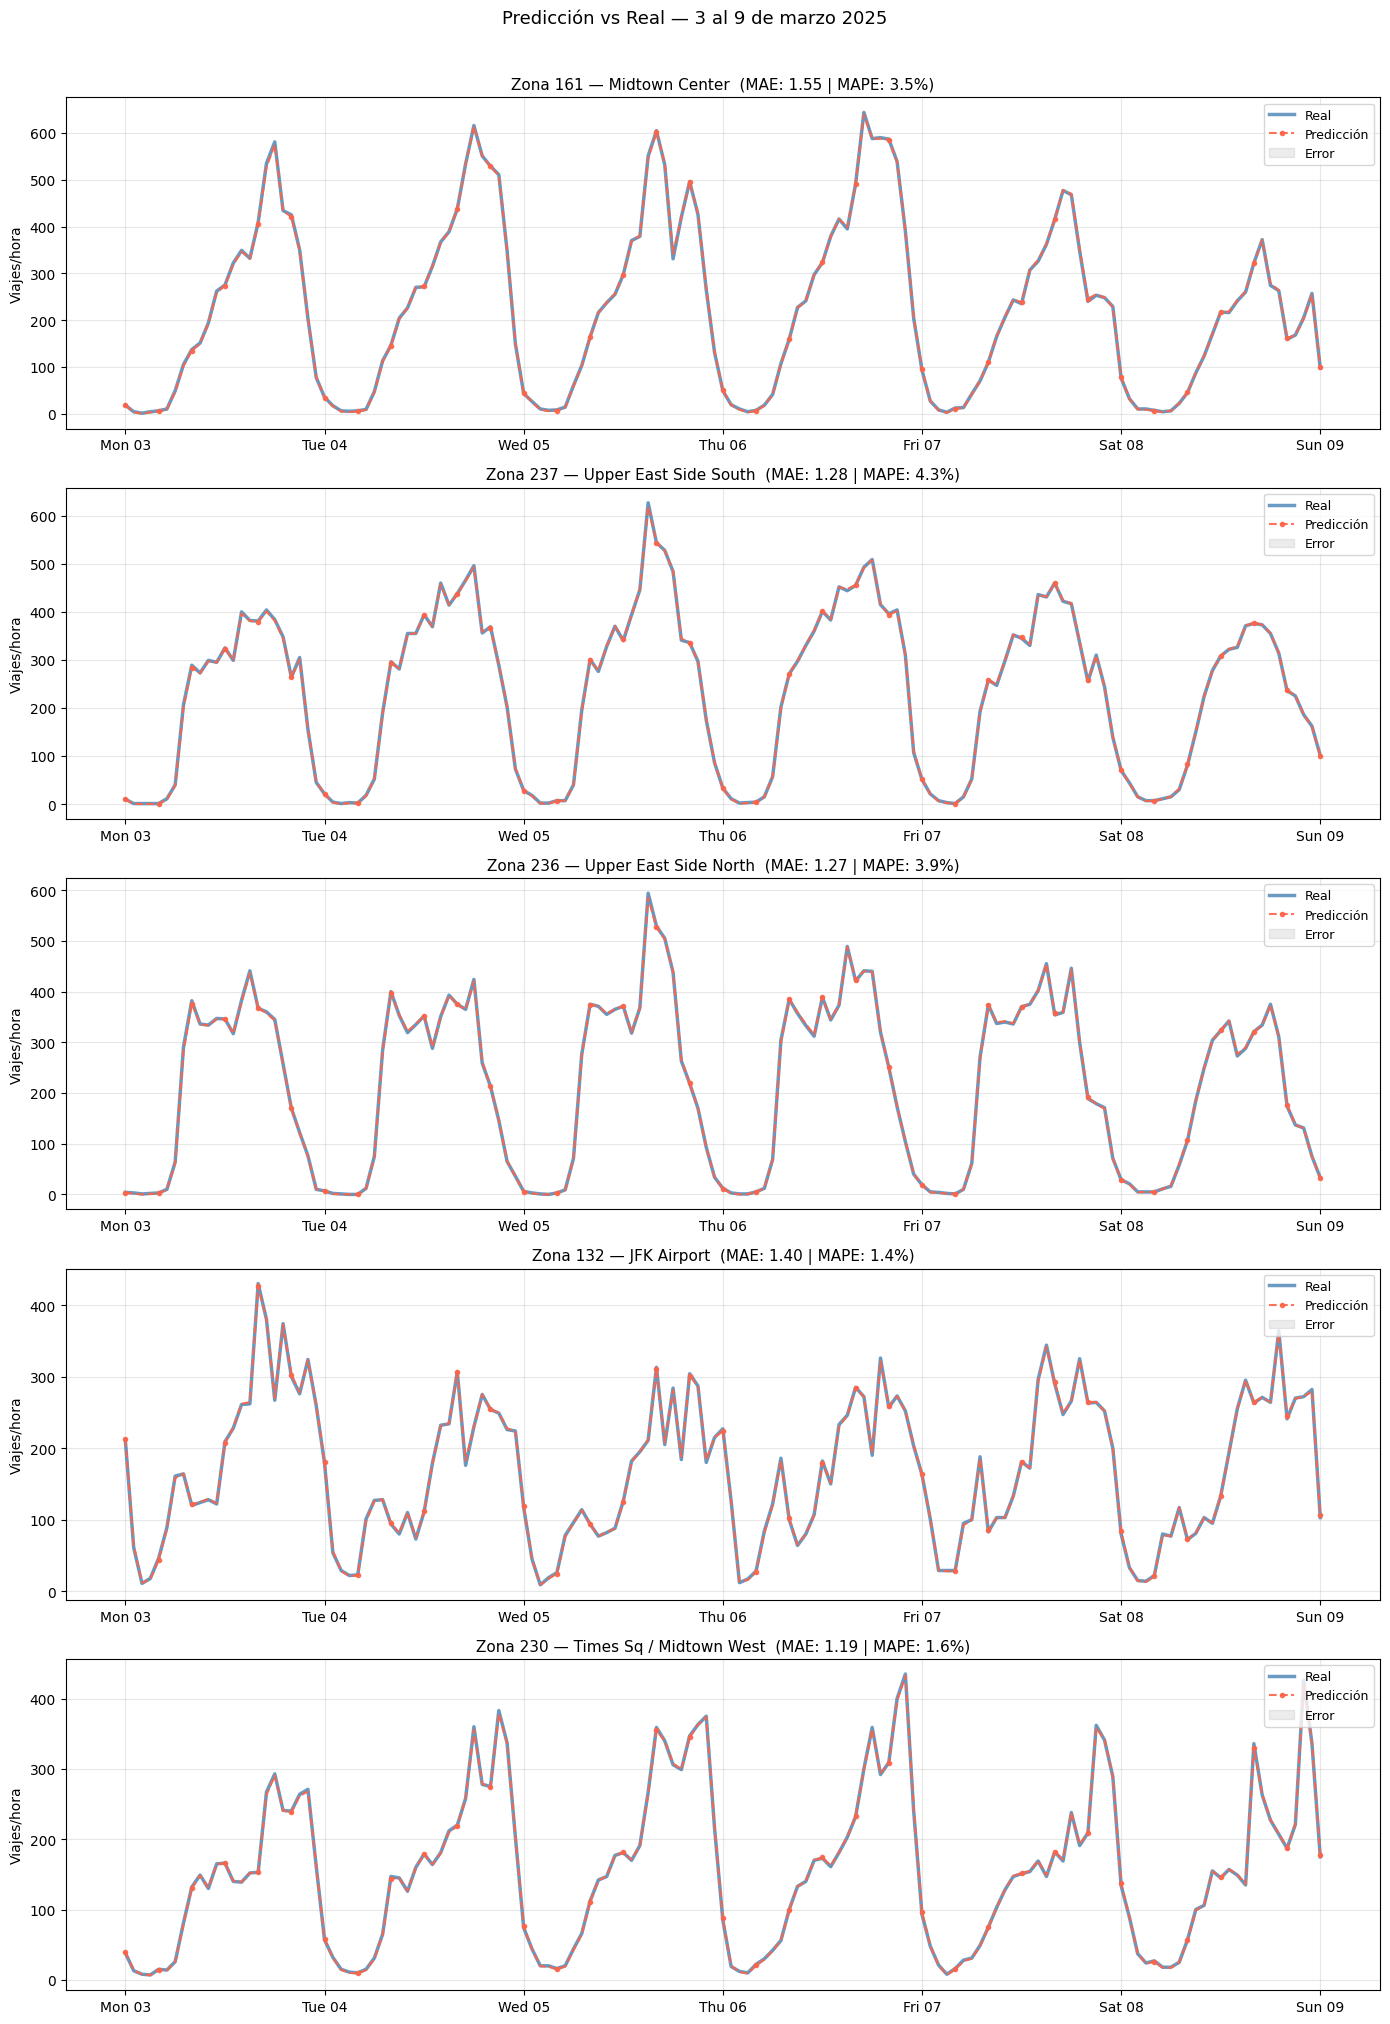

Guardado en reports/figures/predicciones_semana.png


In [14]:
# Semana del 3 al 9 de marzo 2025
SEMANA_INICIO = '2025-03-03'
SEMANA_FIN    = '2025-03-09'

fig, axes = plt.subplots(len(ZONAS), 1, figsize=(14, 4 * len(ZONAS)), sharex=False)

for ax, (zone_id, zone_name) in zip(axes, ZONAS.items()):
    z = test[
        (test['PULocationID'] == zone_id) &
        (test['pickup_datetime'] >= SEMANA_INICIO) &
        (test['pickup_datetime'] <= SEMANA_FIN)
    ].sort_values('pickup_datetime')

    ax.plot(z['pickup_datetime'], z[TARGET], label='Real', linewidth=2.5, color='steelblue', alpha=0.8)
    ax.plot(z['pickup_datetime'], z['y_pred'], label='Predicción', linewidth=1.5,
            color='tomato', linestyle='--', alpha=0.9, marker='o', markersize=3, markevery=4)

    # Error como área sombreada
    ax.fill_between(z['pickup_datetime'], z[TARGET], z['y_pred'], alpha=0.15, color='gray', label='Error')

    mae_z = mean_absolute_error(z[TARGET], z['y_pred'])
    mape_z = 100 * np.mean(np.abs((z[TARGET] - z['y_pred']) / (z[TARGET] + 1)))
    ax.set_title(f'Zona {zone_id} — {zone_name}  (MAE: {mae_z:.2f} | MAPE: {mape_z:.1f}%)', fontsize=11)
    ax.set_ylabel('Viajes/hora')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicción vs Real — 3 al 9 de marzo 2025', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/predicciones_semana.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en reports/figures/predicciones_semana.png')

## 4. Predicción vs Real — mes completo (agregado diario)

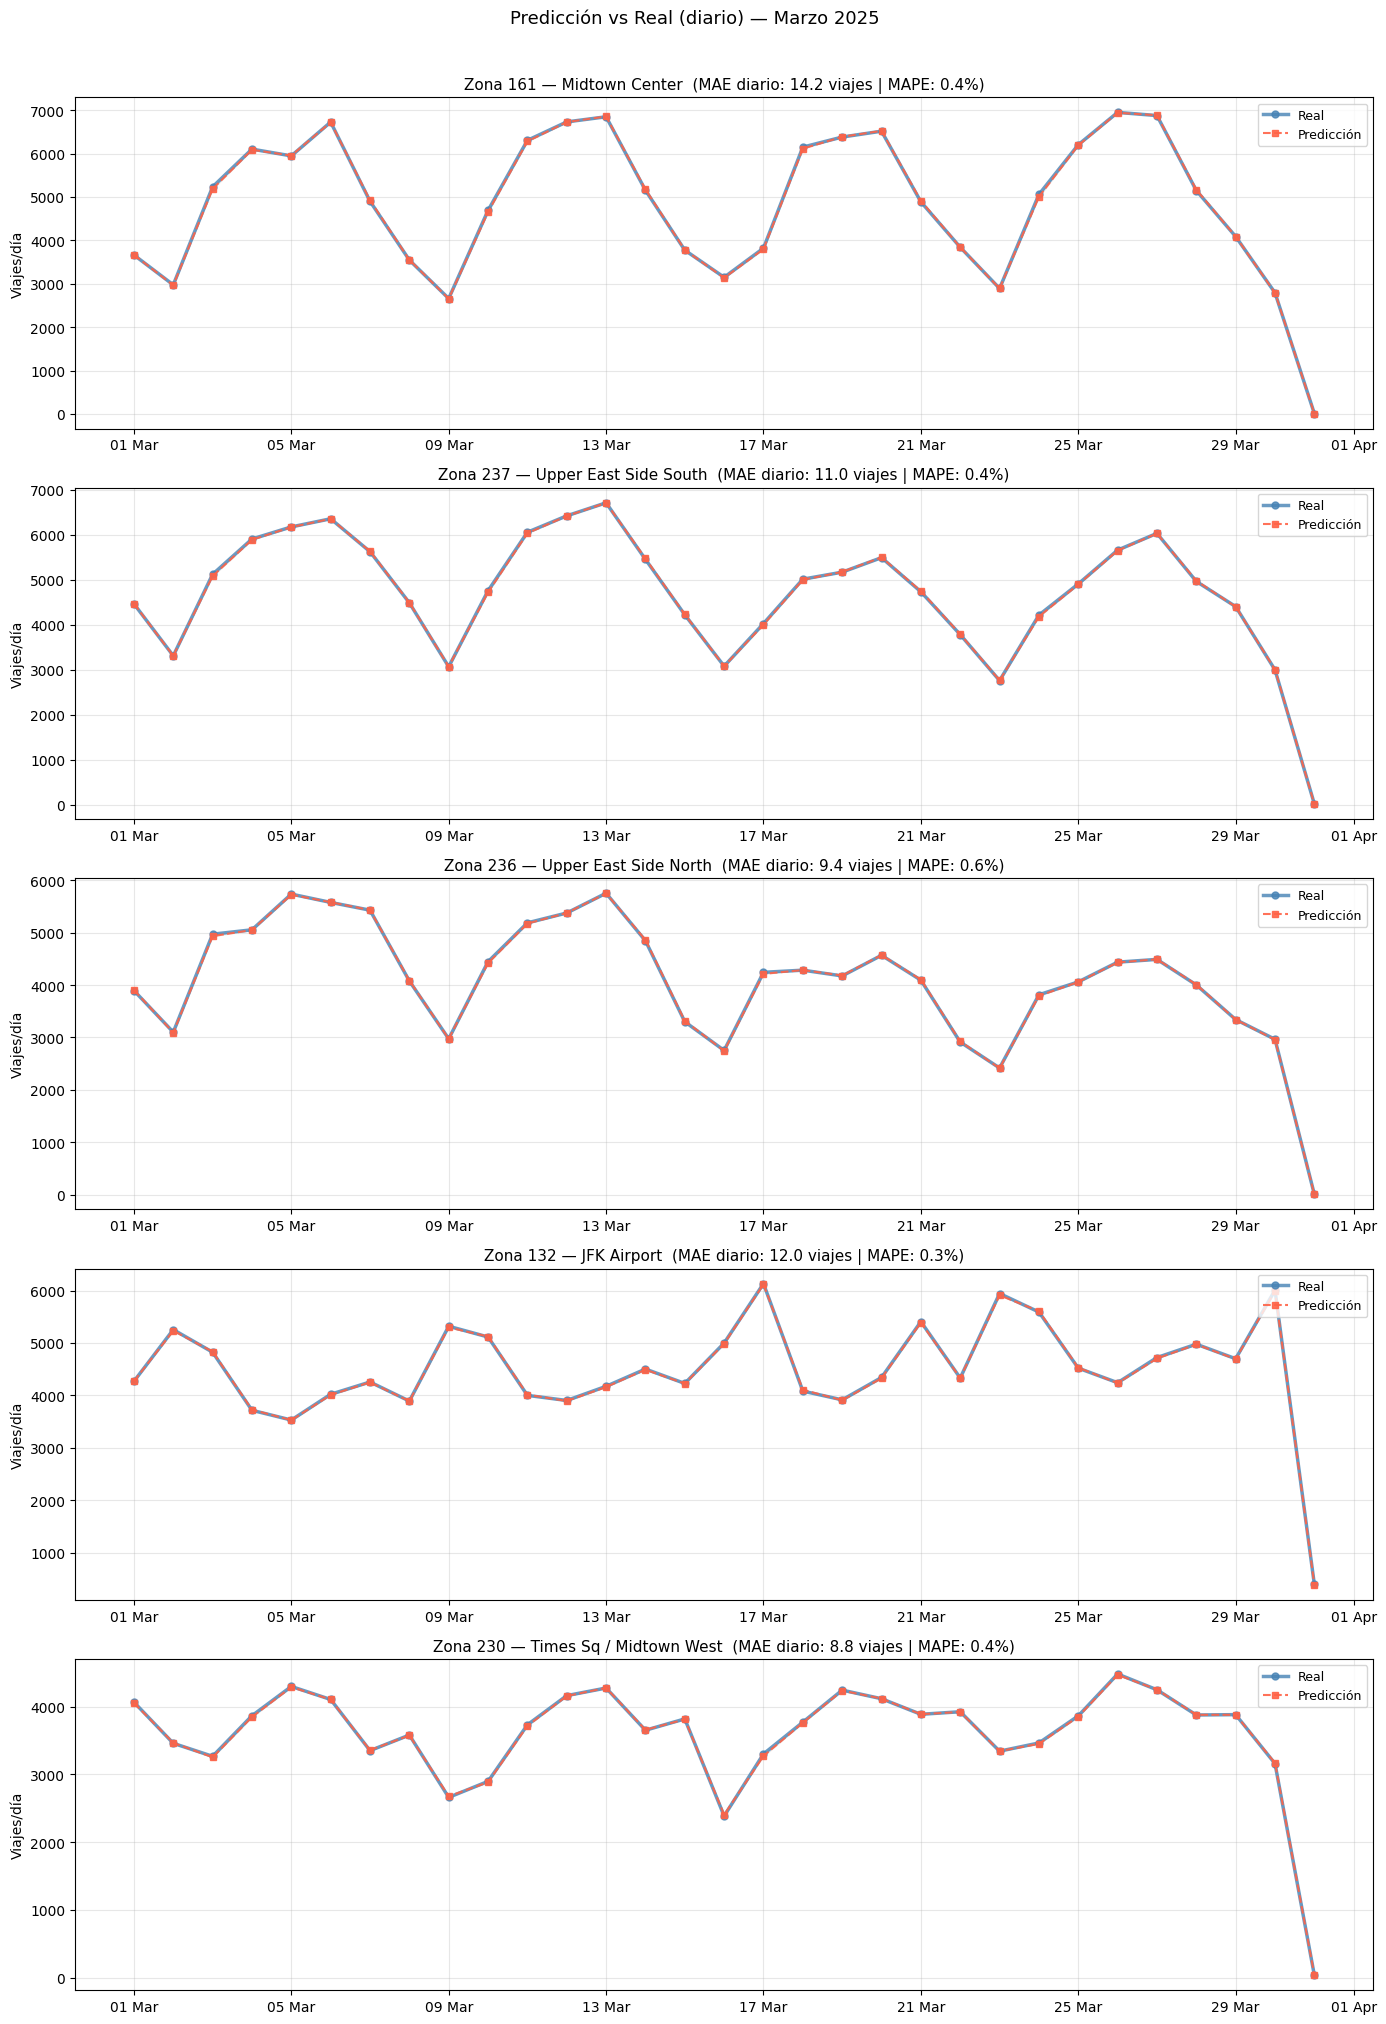

Guardado en reports/figures/predicciones_mes.png


In [15]:
fig, axes = plt.subplots(len(ZONAS), 1, figsize=(14, 4 * len(ZONAS)), sharex=False)

for ax, (zone_id, zone_name) in zip(axes, ZONAS.items()):
    z = test[test['PULocationID'] == zone_id].sort_values('pickup_datetime').copy()
    z['date'] = z['pickup_datetime'].dt.date

    # Agregar por día
    diario = z.groupby('date').agg(
        real=('trip_count', 'sum'),
        pred=('y_pred', 'sum')
    ).reset_index()
    diario['date'] = pd.to_datetime(diario['date'])
    diario['error'] = diario['pred'] - diario['real']

    ax.plot(diario['date'], diario['real'], label='Real', linewidth=2.5, color='steelblue', 
            alpha=0.8, marker='o', markersize=5)
    ax.plot(diario['date'], diario['pred'], label='Predicción', linewidth=1.5,
            color='tomato', linestyle='--', alpha=0.9, marker='s', markersize=4)
    
    # Error como área
    ax.fill_between(diario['date'], diario['real'], diario['pred'], alpha=0.15, color='gray')

    mae_d = mean_absolute_error(diario['real'], diario['pred'])
    mape_d = 100 * np.mean(np.abs(diario['error'] / (diario['real'] + 1)))
    ax.set_title(f'Zona {zone_id} — {zone_name}  (MAE diario: {mae_d:.1f} viajes | MAPE: {mape_d:.1f}%)', fontsize=11)
    ax.set_ylabel('Viajes/día')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicción vs Real (diario) — Marzo 2025', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/predicciones_mes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en reports/figures/predicciones_mes.png')

## 5. Patrón por hora del día — real vs predicción

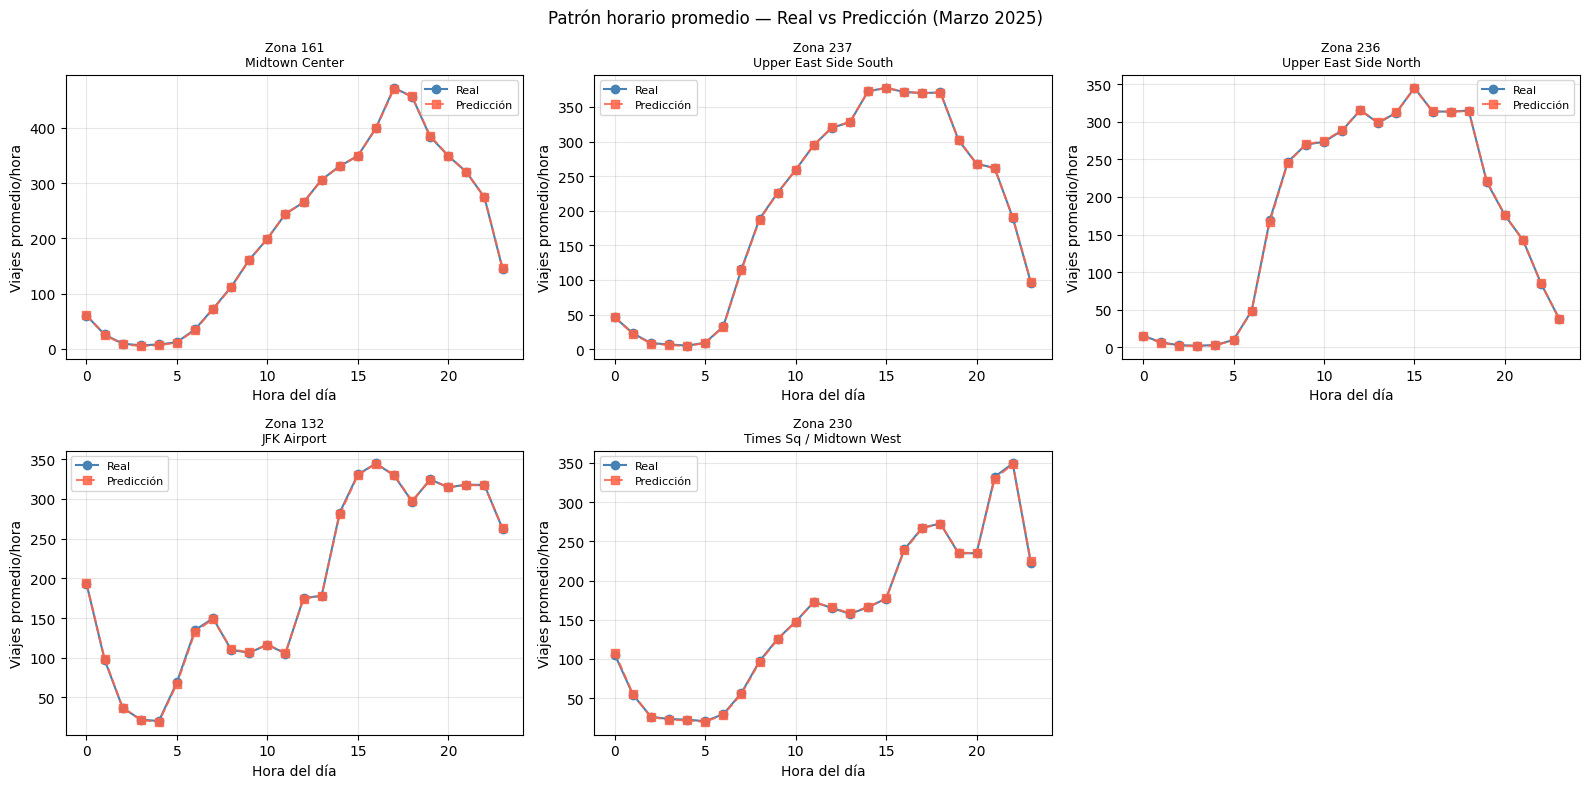

Guardado en reports/figures/patron_horario.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (zone_id, zone_name) in enumerate(ZONAS.items()):
    ax = axes[i]
    z = test[test['PULocationID'] == zone_id].copy()

    por_hora = z.groupby('hour').agg(
        real=('trip_count', 'mean'),
        pred=('y_pred', 'mean')
    ).reset_index()

    ax.plot(por_hora['hour'], por_hora['real'], 'o-', label='Real', color='steelblue', linewidth=1.5)
    ax.plot(por_hora['hour'], por_hora['pred'], 's--', label='Predicción', color='tomato',
            linewidth=1.5, alpha=0.85)
    ax.set_title(f'Zona {zone_id}\n{zone_name}', fontsize=9)
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Viajes promedio/hora')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # ocultar el 6to subplot vacío

plt.suptitle('Patrón horario promedio — Real vs Predicción (Marzo 2025)', fontsize=12)
plt.tight_layout()
plt.savefig('../../reports/figures/patron_horario.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en reports/figures/patron_horario.png')

## 6. Distribución del error de predicción

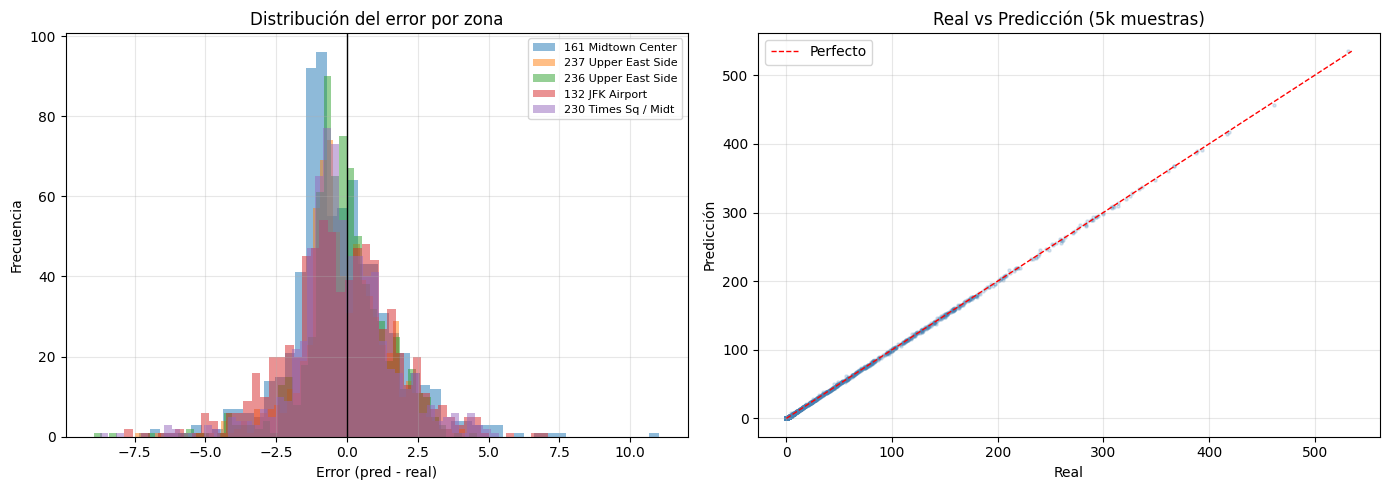

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error absoluto por zona
test_top = test[test['PULocationID'].isin(ZONAS.keys())].copy()
test_top['error'] = test_top['y_pred'] - test_top[TARGET]

for zone_id, zone_name in ZONAS.items():
    z = test_top[test_top['PULocationID'] == zone_id]['error']
    axes[0].hist(z, bins=50, alpha=0.5, label=f'{zone_id} {zone_name[:15]}')

axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Error (pred - real)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del error por zona')
axes[0].legend(fontsize=8)

# Real vs predicción (scatter) — usar todo el test set
test_scatter = test.copy()
test_scatter['error'] = test_scatter['y_pred'] - test_scatter[TARGET]
sample_size = min(5000, len(test_scatter))
sample = test_scatter.sample(sample_size, random_state=42)
axes[1].scatter(sample[TARGET], sample['y_pred'], alpha=0.2, s=5, color='steelblue')
max_val = max(sample[TARGET].max(), sample['y_pred'].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfecto')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Predicción')
axes[1].set_title('Real vs Predicción (5k muestras)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../../reports/figures/error_prediccion.png', dpi=120, bbox_inches='tight')
plt.show()